In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats

import scienceplots
plt.style.use('science')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

# Compute and plot percentiles for all 405 maps in the CV set

In [2]:
dset_size      = 405
k_min, k_max   = 2., 45
k_smooth_array = np.logspace(np.log10(k_min), np.log10(k_max), num=10)
field       = 'Mtot'

logE_A = np.load(f'results/{field}_log_evidence_Astrid_CV.npy')
logE_I = np.load(f'results/{field}_log_evidence_IllustrisTNG_CV.npy')
logE_S = np.load(f'results/{field}_log_evidence_SIMBA_CV.npy')

# Compute percentiles of SIMBA and IllustrisTNG wrt Astrid CV set
percentile_S, percentile_I = [], []
for i, k_smooth in enumerate(k_smooth_array):
    percentile_S.append(np.array([stats.percentileofscore(logE_A[i], logE) for logE in logE_S[i]]))
    percentile_I.append(np.array([stats.percentileofscore(logE_A[i], logE) for logE in logE_I[i]]))

percentile_S = np.array(percentile_S)
percentile_I = np.array(percentile_I)

# Compute percentiles of fields from Astrid CV set with leave-one-out approach
percentile_A = []
for i, k_smooth in enumerate(k_smooth_array):
    percentile_A_k = []
    for j in range(dset_size):
        logE_A_temp = np.delete(logE_A[i], j)
        percentile_A_k.append(stats.percentileofscore(logE_A_temp, logE_A[i][j]))
    percentile_A.append(np.array(percentile_A_k))
percentile_A = np.array(percentile_A)

# Save results for plotting.
results_dir = Path("results/")
np.save(results_dir / f'{field}_log_evidence_percentile_Astrid_CV.npy', percentile_A)
np.save(results_dir / f'{field}_log_evidence_percentile_SIMBA_CV.npy', percentile_S)
np.save(results_dir / f'{field}_log_evidence_percentile_IllustrisTNG_CV.npy', percentile_I)

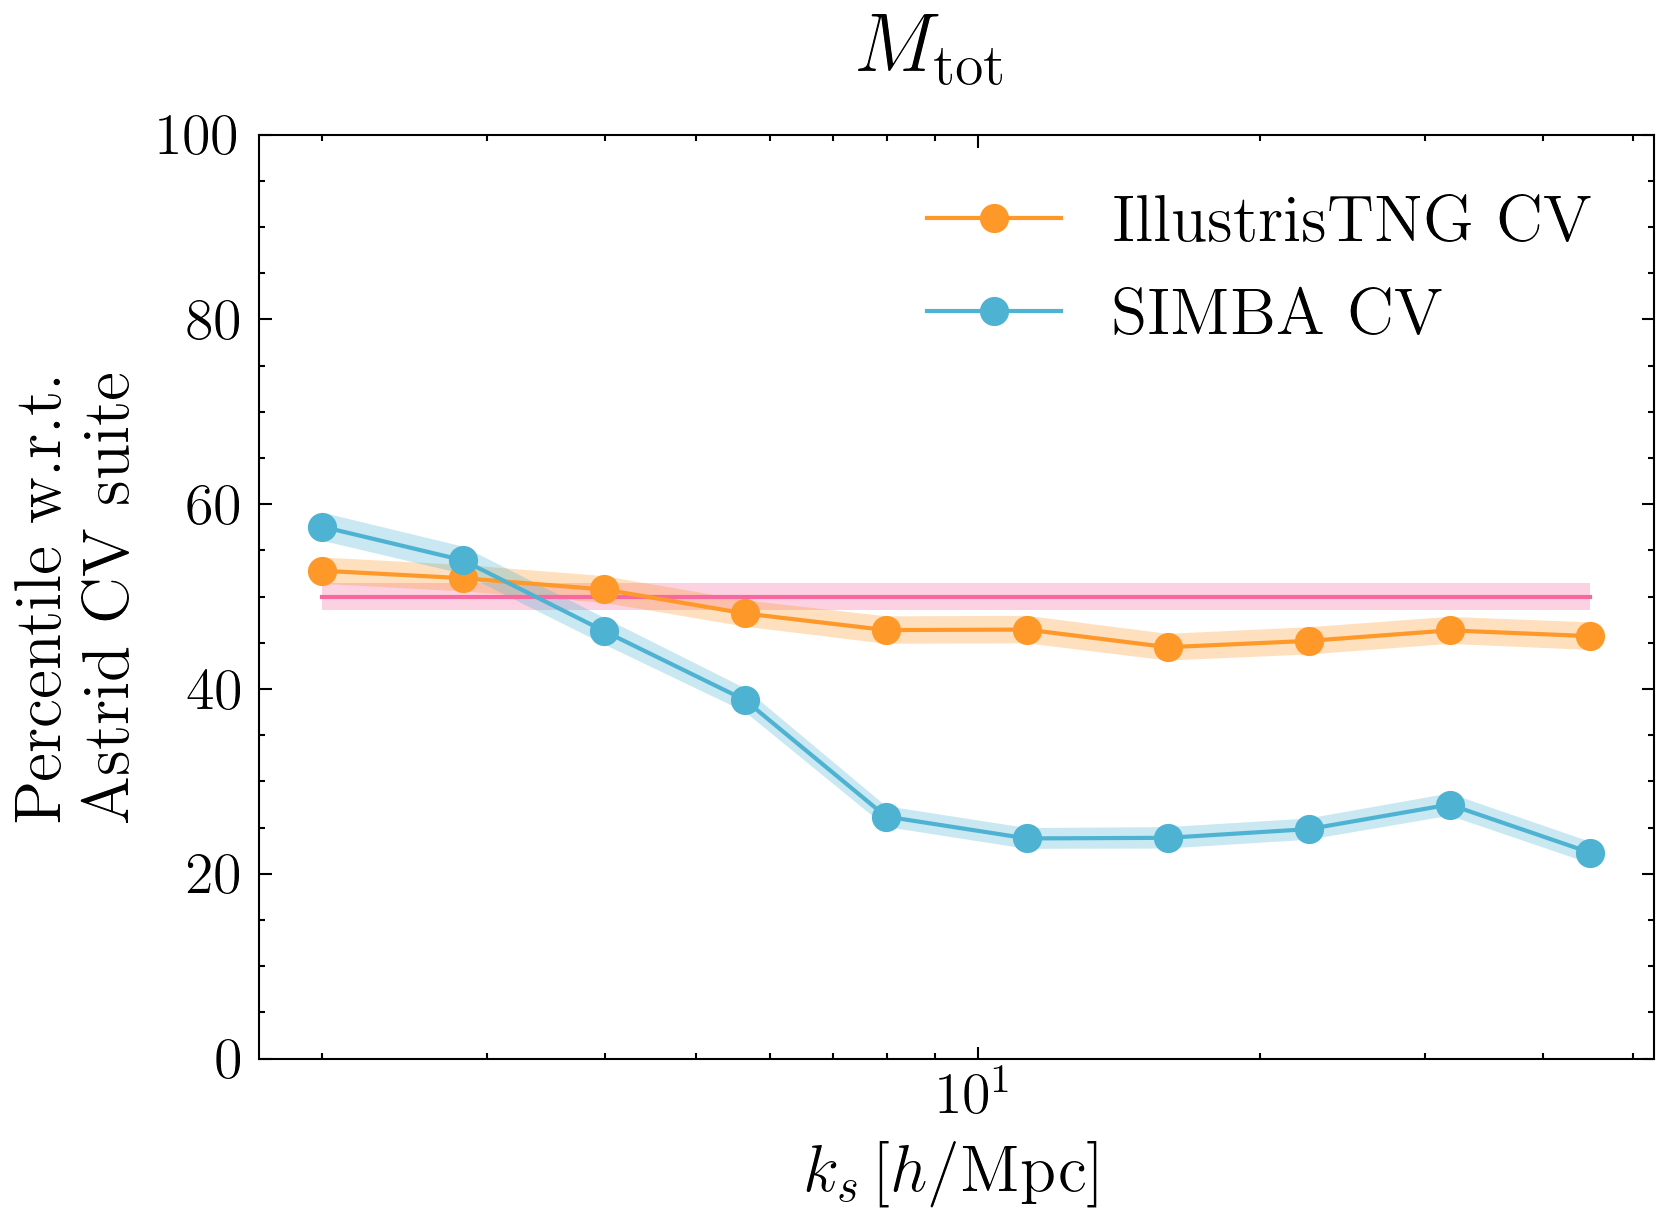

In [3]:
colors = ['#f768a1', '#fe9929', '#4eb3d3', ]

f, ax1 = plt.subplots(1, 1, figsize=(6, 4))
f.suptitle(r'$M_{\mathrm{tot}}$', fontsize=20)

ax1.plot(k_smooth_array, percentile_A.mean(axis=1), c=colors[0],)
ax1.fill_between(k_smooth_array, 
                 percentile_A.mean(axis=1) + percentile_A.std(axis=1)/np.sqrt(dset_size), 
                 percentile_A.mean(axis=1) - percentile_A.std(axis=1)/np.sqrt(dset_size), 
                 facecolor=colors[0], alpha=0.3,)


ax1.plot(k_smooth_array, percentile_I.mean(axis=1),c=colors[1], marker='o', label='IllustrisTNG CV' )
ax1.fill_between(k_smooth_array,  
                 percentile_I.mean(axis=1) + percentile_I.std(axis=1)/np.sqrt(dset_size),
                 percentile_I.mean(axis=1) - percentile_I.std(axis=1)/np.sqrt(dset_size), 
                 facecolor=colors[1], alpha=0.3,)

ax1.plot(k_smooth_array, percentile_S.mean(axis=1), c=colors[2], marker='o', label='SIMBA CV')
ax1.fill_between(k_smooth_array, 
                 percentile_S.mean(axis=1) + percentile_S.std(axis=1)/np.sqrt(dset_size), 
                 percentile_S.mean(axis=1) - percentile_S.std(axis=1)/np.sqrt(dset_size),
                 facecolor=colors[2], alpha=0.3,)

ax1.set_ylabel('Percentile w.r.t. \n Astrid CV suite', fontsize=16)
ax1.set_xlabel(r'$ k_s \, [h/\mathrm{Mpc}]$', fontsize=16)
ax1.set_ylim(0, 100)
ax1.set_xscale('log')
ax1.legend(loc='best', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
plt.savefig(f'plots/3_evidence_percentile_{field}.pdf')


In [4]:
percentile_S.std(axis=1)/np.sqrt(dset_size)

array([1.52223111, 1.48045688, 1.44314061, 1.27723611, 1.12637195,
       1.12608116, 1.15618043, 1.15125831, 1.20734436, 1.17297565])

In [5]:
dset_size

405